# Setup & Libraries

In [7]:
!pip install thop umap-learn

import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.models as models
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import umap
from sklearn.metrics import silhouette_score, accuracy_score, f1_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import label_binarize
from thop import profile

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_dir = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training'
test_dir = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing'

# base_transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor()
# ])

# ssl_transform = transforms.Compose([
#     transforms.RandomResizedCrop(224),
#     transforms.RandomHorizontalFlip(),
#     transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
#     transforms.RandomGrayscale(p=0.2),
#     transforms.ToTensor(),
# ])


base_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

ssl_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.4, 0.4, 0.4, 0.0),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(root=train_dir, transform=base_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=base_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

# SimCLR Architecture & Loss

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from mamba_ssm import Mamba


class ConvBNReLU(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class ResidualCNNBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = ConvBNReLU(channels, channels, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(channels)
        )
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.conv2(out)
        out = out + identity
        return self.act(out)


class AttentionPooling(nn.Module):
    def __init__(self, dim):
        super().__init__()
        hidden = max(dim // 2, 1)
        self.attn = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, 1)
        )

    def forward(self, x):
        # x: [B, N, C]
        w = self.attn(x)                 # [B, N, 1]
        w = torch.softmax(w, dim=1)      # [B, N, 1]
        return torch.sum(w * x, dim=1)   # [B, C]


class HybridCNNMambaEncoder(nn.Module):
    def __init__(self, in_channels=1, feature_dim=512, mamba_layers=2):
        super().__init__()

        self.stem = nn.Sequential(
            ConvBNReLU(in_channels, 64, kernel_size=7, stride=2, padding=3),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.cnn_stage1 = nn.Sequential(
            ResidualCNNBlock(64),
            ResidualCNNBlock(64)
        )

        self.downsample1 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )

        self.cnn_stage2 = nn.Sequential(
            ResidualCNNBlock(128),
            ResidualCNNBlock(128)
        )

        self.downsample2 = nn.Sequential(
            nn.Conv2d(128, feature_dim, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(feature_dim),
            nn.ReLU(inplace=True)
        )

        self.cnn_stage3 = nn.Sequential(
            ResidualCNNBlock(feature_dim),
            ResidualCNNBlock(feature_dim)
        )

        self.mamba_blocks = nn.ModuleList([
            Mamba(
                d_model=feature_dim,
                d_state=16,
                d_conv=4,
                expand=2
            )
            for _ in range(mamba_layers)
        ])

        self.pool = AttentionPooling(feature_dim)
        self.feature_dim = feature_dim

    def forward(self, x):
        x = self.stem(x)
        x = self.cnn_stage1(x)
        x = self.downsample1(x)
        x = self.cnn_stage2(x)
        x = self.downsample2(x)
        x = self.cnn_stage3(x)

        b, c, h, w = x.shape
        x = x.flatten(2).transpose(1, 2)   # [B, N, C]

        for blk in self.mamba_blocks:
            x = x + blk(x)

        h = self.pool(x)                   # [B, feature_dim]
        return h


class SimCLR_CNNMamba(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.encoder = HybridCNNMambaEncoder(in_channels=1, feature_dim=512, mamba_layers=2)
        dim_mlp = self.encoder.feature_dim
        self.projector = nn.Sequential(
            nn.Linear(dim_mlp, dim_mlp),
            nn.ReLU(inplace=True),
            nn.Linear(dim_mlp, out_dim)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return h, z


def nt_xent_loss(z1, z2, temperature=0.5):
    """
    Stable SimCLR-style NT-Xent loss.
    z1, z2: [B, D]
    """
    z1 = F.normalize(z1, dim=1, eps=1e-8)
    z2 = F.normalize(z2, dim=1, eps=1e-8)

    z = torch.cat([z1, z2], dim=0)          # [2B, D]
    sim = torch.matmul(z, z.T) / temperature # [2B, 2B]

    n = sim.size(0)
    diag_mask = torch.eye(n, device=sim.device, dtype=torch.bool)
    sim = sim.masked_fill(diag_mask, -1e9)

    targets = torch.arange(n, device=sim.device)
    targets = torch.where(targets < n // 2, targets + n // 2, targets - n // 2)

    return F.cross_entropy(sim, targets)

# Pretraining & Learning Curve

Epoch [1/10], Loss: 3.1145
Epoch [2/10], Loss: 2.6303
Epoch [3/10], Loss: 2.4117
Epoch [4/10], Loss: 2.2501
Epoch [5/10], Loss: 2.1648
Epoch [6/10], Loss: 2.1055
Epoch [7/10], Loss: 2.0800
Epoch [8/10], Loss: 2.0564
Epoch [9/10], Loss: 2.0302
Epoch [10/10], Loss: 2.0027

Pretraining Time: 944.08 seconds


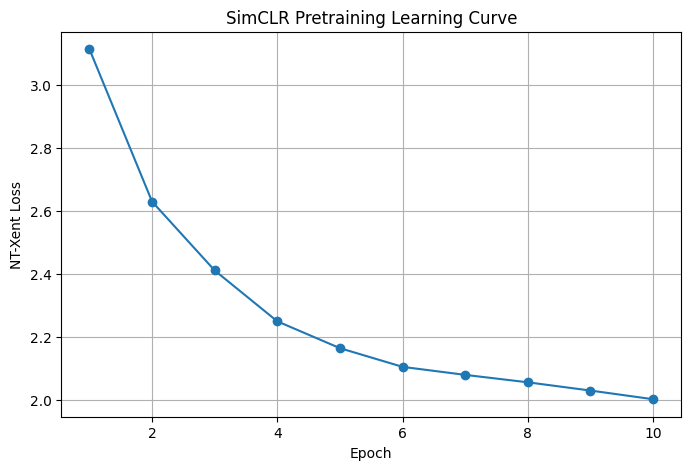

In [12]:
import os
import time
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Model, optimizer, and training setup
model = SimCLR_CNNMamba().to(device)

# AdamW is often a bit more stable than Adam for this kind of training
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

epochs = 10
pretrain_losses = []
start_time = time.time()

for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    num_batches = 0

    for images, _ in train_loader:
        # images are still on CPU here
        # create two augmented views of each image
        img1 = torch.stack([ssl_transform(TF.to_pil_image(img)) for img in images]).to(device)
        img2 = torch.stack([ssl_transform(TF.to_pil_image(img)) for img in images]).to(device)

        optimizer.zero_grad(set_to_none=True)

        # Full precision for stability
        _, z1 = model(img1)
        _, z2 = model(img2)

        loss = nt_xent_loss(z1, z2, temperature=0.5)

        # Skip a batch if something goes wrong numerically
        if not torch.isfinite(loss):
            print(f"Non-finite loss detected at epoch {epoch+1}, batch {num_batches+1}. Skipping batch.")
            continue

        loss.backward()

        # Optional but useful for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    avg_loss = total_loss / max(num_batches, 1)
    pretrain_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

print(f"\nPretraining Time: {time.time() - start_time:.2f} seconds")
torch.save(model.state_dict(), "simclr_cnn_mamba.pth")

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), pretrain_losses, marker='o')
plt.title("SimCLR Pretraining Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("NT-Xent Loss")
plt.grid(True)
plt.show()

# Feature Extraction & Embeddings

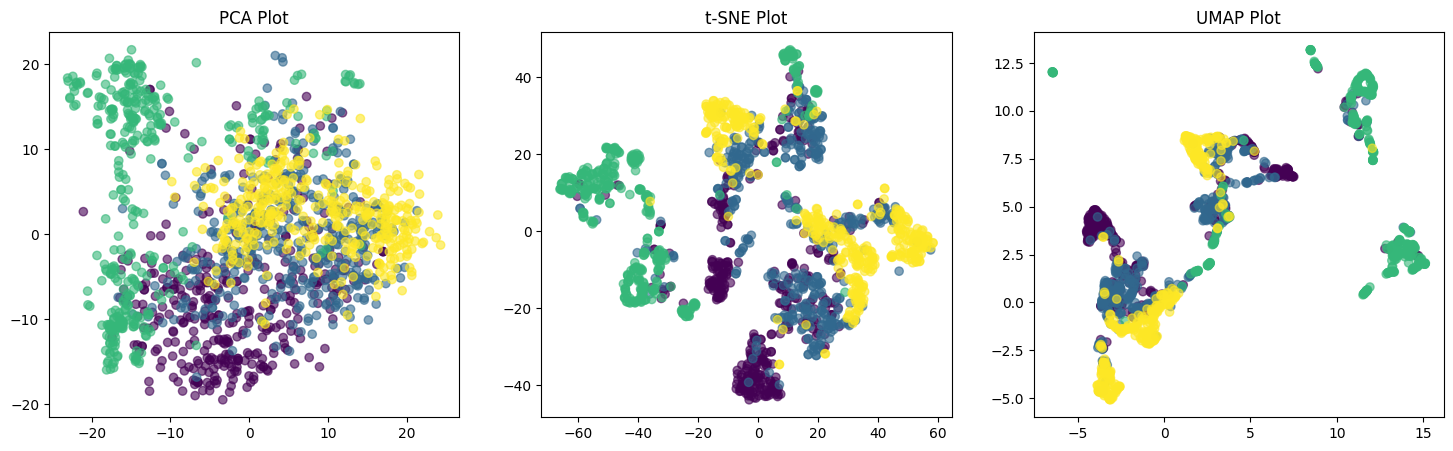

Silhouette Score (t-SNE): 0.1042


In [13]:
def extract_features(model, dataloader):
    model.eval()
    features, labels = [], []
    with torch.no_grad():
        for imgs, lbls in dataloader:
            imgs = imgs.to(device)
            h, _ = model(imgs)
            features.append(h.cpu().numpy())
            labels.append(lbls.numpy())
    return np.concatenate(features), np.concatenate(labels)


X_train, y_train = extract_features(model, train_loader)
X_test, y_test = extract_features(model, test_loader)

pca_res = PCA(n_components=2).fit_transform(X_test)
tsne_res = TSNE(n_components=2, perplexity=30).fit_transform(X_test)
umap_res = umap.UMAP(n_neighbors=15, min_dist=0.1).fit_transform(X_test)

plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.scatter(pca_res[:, 0], pca_res[:, 1], c=y_test, cmap='viridis', alpha=0.6)
plt.title('PCA Plot')

plt.subplot(1, 3, 2)
plt.scatter(tsne_res[:, 0], tsne_res[:, 1], c=y_test, cmap='viridis', alpha=0.6)
plt.title('t-SNE Plot')

plt.subplot(1, 3, 3)
plt.scatter(umap_res[:, 0], umap_res[:, 1], c=y_test, cmap='viridis', alpha=0.6)
plt.title('UMAP Plot')

plt.show()

print(f"Silhouette Score (t-SNE): {silhouette_score(tsne_res, y_test):.4f}")

# Shallow Heads & Fine-Tuning

In [16]:
start_train = time.time()
lp_model = MLPClassifier(hidden_layer_sizes=(), max_iter=1000)
lp_model.fit(X_train, y_train)
print(f"Linear Probe Train Time: {time.time() - start_train:.4f} sec")

start_test = time.time()
y_pred_lp = lp_model.predict(X_test)
y_prob_lp = lp_model.predict_proba(X_test)
print(f"Linear Probe Test Time: {time.time() - start_test:.4f} sec\n")

shallow_heads = {
    "Linear Probe": lp_model,
    "MLP (1-Layer)": MLPClassifier(hidden_layer_sizes=(512,), max_iter=1000).fit(X_train, y_train),
    "SVM": SVC(probability=True).fit(X_train, y_train),
    "Decision Tree": DecisionTreeClassifier().fit(X_train, y_train),
    "Random Forest": RandomForestClassifier().fit(X_train, y_train)
}

for name, clf in shallow_heads.items():
    pred = clf.predict(X_test)
    print(f"{name} -> Acc: {accuracy_score(y_test, pred):.4f}, F1: {f1_score(y_test, pred, average='weighted'):.4f}")


class FineTuneModel(nn.Module):
    def __init__(self, base_encoder, num_classes):
        super().__init__()
        self.encoder = base_encoder
        self.classifier = nn.Linear(self.encoder.feature_dim, num_classes)

    def forward(self, x):
        h = self.encoder(x)
        return self.classifier(h)


ft_model = FineTuneModel(copy.deepcopy(model.encoder), len(train_dataset.classes)).to(device)
optimizer_ft = optim.Adam(ft_model.parameters(), lr=1e-5)
criterion_ft = nn.CrossEntropyLoss()

for epoch in range(5):
    ft_model.train()
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        loss = criterion_ft(ft_model(imgs), lbls)
        optimizer_ft.zero_grad()
        loss.backward()
        optimizer_ft.step()
    print(f"Fine-tuning Epoch {epoch+1}/5 complete.")

ft_model.eval()
correct, total = 0, 0
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        predicted = torch.max(ft_model(imgs).data, 1)[1]
        total += lbls.size(0)
        correct += (predicted == lbls).sum().item()

print(f"\nFull Fine-tuning Accuracy: {100 * correct / total:.2f}%")

Linear Probe Train Time: 3.2104 sec
Linear Probe Test Time: 0.0033 sec

Linear Probe -> Acc: 0.8675, F1: 0.8644
MLP (1-Layer) -> Acc: 0.9131, F1: 0.9110
SVM -> Acc: 0.8394, F1: 0.8366
Decision Tree -> Acc: 0.8438, F1: 0.8417
Random Forest -> Acc: 0.8862, F1: 0.8836
Fine-tuning Epoch 1/5 complete.
Fine-tuning Epoch 2/5 complete.
Fine-tuning Epoch 3/5 complete.
Fine-tuning Epoch 4/5 complete.
Fine-tuning Epoch 5/5 complete.

Full Fine-tuning Accuracy: 90.81%


# All Detailed Metrics & Graphs

k-NN (k=1) Accuracy: 0.9237
k-NN (k=5) Accuracy: 0.8712
k-NN (k=20) Accuracy: 0.8263

Detailed Classification Report:
              precision    recall  f1-score   support

      glioma       0.94      0.68      0.79       400
  meningioma       0.77      0.86      0.81       400
     notumor       0.87      0.98      0.93       400
   pituitary       0.92      0.95      0.93       400

    accuracy                           0.87      1600
   macro avg       0.87      0.87      0.86      1600
weighted avg       0.87      0.87      0.86      1600



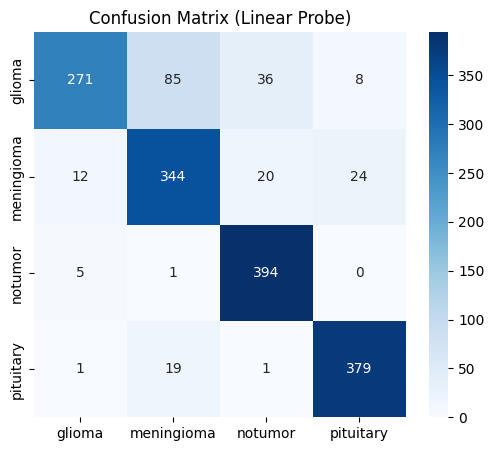

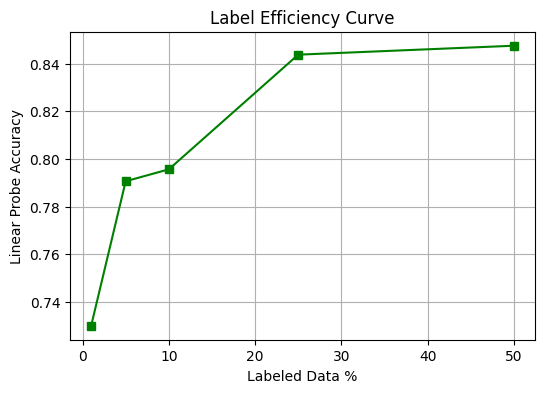

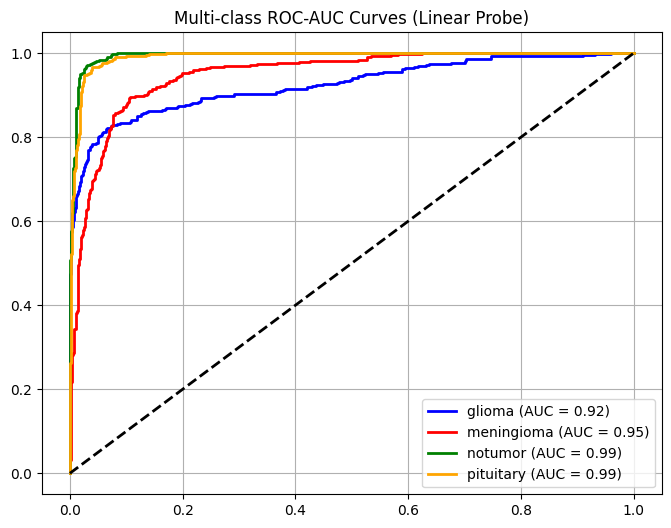


GFLOPs: 3.0235


In [19]:
for k in [1, 5, 20]:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    print(f"k-NN (k={k}) Accuracy: {knn.score(X_test, y_test):.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_lp, target_names=train_dataset.classes))

plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix(y_test, y_pred_lp),
    annot=True,
    fmt='d',
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes,
    cmap="Blues"
)
plt.title("Confusion Matrix (Linear Probe)")
plt.show()


def label_efficiency_curve(percentages):
    eff_accs = []
    for p in percentages:
        n = max(1, int(len(X_train) * (p / 100)))
        idx = np.random.choice(len(X_train), n, replace=False)
        lp = MLPClassifier(hidden_layer_sizes=(), max_iter=2000).fit(X_train[idx], y_train[idx])
        eff_accs.append(lp.score(X_test, y_test))
    return eff_accs


p_list = [1, 5, 10, 25, 50]
plt.figure(figsize=(6, 4))
plt.plot(p_list, label_efficiency_curve(p_list), marker='s', color='green')
plt.title("Label Efficiency Curve")
plt.xlabel("Labeled Data %")
plt.ylabel("Linear Probe Accuracy")
plt.grid(True)
plt.show()


classes_list = list(range(len(train_dataset.classes)))
y_test_bin = label_binarize(y_test, classes=classes_list)
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange']
for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_lp[:, i])
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{train_dataset.classes[i]} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('Multi-class ROC-AUC Curves (Linear Probe)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# For 1-channel MRI input
input_dummy = torch.randn(1, 1, 224, 224).to(device)
macs, params = profile(model.encoder, inputs=(input_dummy,), verbose=False)
print(f"\nGFLOPs: {macs / 1e9:.4f}")